# Review  Parallel

In [1]:
from langgraph.graph import StateGraph,START,END
from langchain_groq import ChatGroq
from typing import TypedDict, Literal
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import os
load_dotenv()

e:\Langgraph\myvenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
api_key = os.getenv('GROQ_API_KEY')
model = ChatGroq(groq_api_key=api_key,model="llama-3.1-8b-instant")

In [3]:
# becouse i give only two condition "positive" and "negative"
# in the from of Json

class SentimentSchema(BaseModel):

    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the Review')

In [4]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [5]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

In [16]:
prompt = "i love you"

structured_model.invoke(prompt).sentiment        #model_dump()

'positive'

In [19]:
structured_model2.invoke(prompt).model_dump()

{'issue_type': 'Other', 'tone': 'calm', 'urgency': 'low'}

In [8]:
class ReviewState(TypedDict):

    review : str
    sentiment: Literal['positive', 'negative']
    diognosis: dict
    responce: str

In [ ]:
def find_sentiment(state: ReviewState):

    prompt = f'For the following review find out the sentiment \n {state["review"]}'

    sentiment = structured_model.invoke(prompt).sentiment

    return {'sentiment': sentiment}

def check_condition(state:ReviewState) -> Literal["diognosis_run", "positive_run"]:

    if state['sentiment'] == "positive":
        return 'positive_run'
    else:
        return 'diognosis_run'
    

def diognosis_run(state: ReviewState):
    
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
    """

    responce = structured_model2.invoke(prompt)

    return{'diognosis': responce.model_dump()}

def positive_run(state:ReviewState):

    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
    Also, kindly ask the user to leave feedback on our website.
    """

    responce = model.invoke(prompt)

    return {'responce': responce}

def negative_run(state:ReviewState):

    diognosis = state['diognosis']

    prompt = f"""You are a support assistant.
    The user had a '{diognosis['issue_type']}' issue, sounded '{diognosis['tone']}', and marked urgency as '{diognosis['urgency']}'.
    Write an empathetic, helpful resolution message.
    """

    responce = model.invoke(prompt).content

    return {'responce': responce}


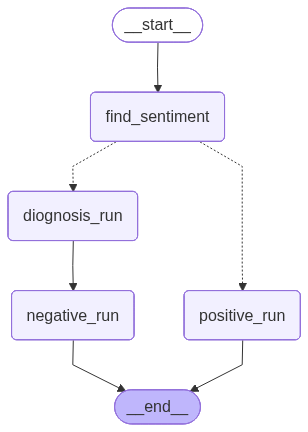

In [10]:
graph = StateGraph(ReviewState)


# Node 
graph.add_node("find_sentiment", find_sentiment)
graph.add_node("diognosis_run", diognosis_run)
graph.add_node("positive_run", positive_run)
graph.add_node("negative_run", negative_run)

# Edge
graph.add_edge(START,'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_condition)
graph.add_edge('positive_run', END)
graph.add_edge('diognosis_run', 'negative_run')
graph.add_edge('negative_run', END)

workflow = graph.compile()
workflow

In [12]:
initial_state = {
    'review': """I recently purchased this software from the e-commerce site, and I am extremely frustrated. 
The app keeps crashing whenever I try to upload a file larger than 5MB. 
I followed all the instructions carefully, reinstalled it multiple times, and even updated my device, but the problem persists. 
Customer support was slow to respond, and the solution provided did not fix the issue. 
Additionally, some features are missing compared to the description, and the overall performance is far below my expectations. 
This has been a very disappointing experience, and I am considering requesting a refund. 
I hope the development team takes this feedback seriously and improves the product stability and functionality."""
}

workflow.invoke(initial_state)

{'review': 'I recently purchased this software from the e-commerce site, and I am extremely frustrated. \nThe app keeps crashing whenever I try to upload a file larger than 5MB. \nI followed all the instructions carefully, reinstalled it multiple times, and even updated my device, but the problem persists. \nCustomer support was slow to respond, and the solution provided did not fix the issue. \nAdditionally, some features are missing compared to the description, and the overall performance is far below my expectations. \nThis has been a very disappointing experience, and I am considering requesting a refund. \nI hope the development team takes this feedback seriously and improves the product stability and functionality.',
 'sentiment': 'negative',
 'diognosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'},
 'responce': "Subject: Urgent Resolution for Your 'Bug' Issue\n\nDear [User's Name],\n\nI'm so sorry to hear that you're experiencing a 'bug' issue with our system